In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

(100, 6)
Fit: y = 4.71 * e^(-0.92 * x)
0.7906732087457313


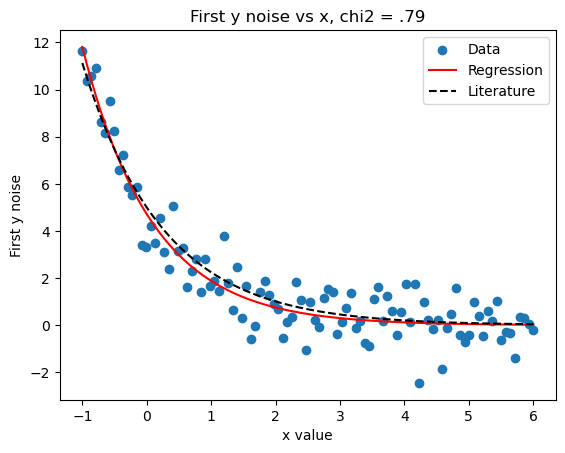

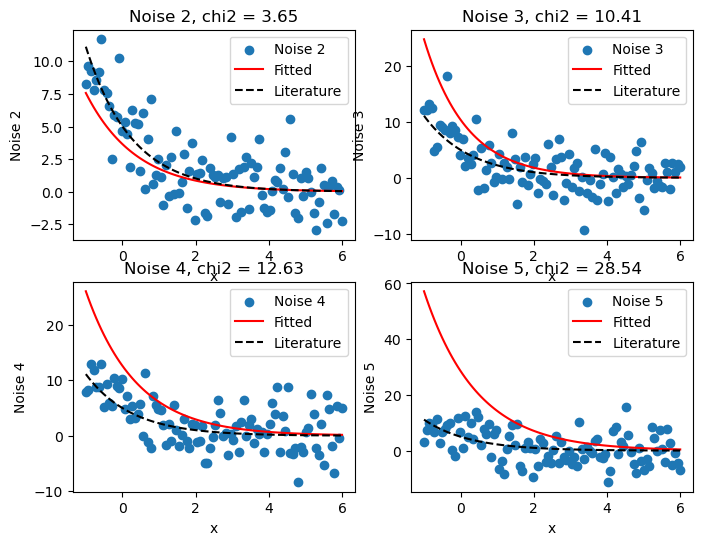

In [66]:
df = pd.read_csv("noisy_curvefit_data.csv")
print(df.shape)
#100 rows, 6 columns
df.head(5)
df.tail(5)
#x, y_noise_1 through y_noise_5
x = df["x"]
y = df["y_noise_1"]

def model(x, A, k):
    return A * np.exp(-k*x)
p0 = [1,1]

popt, pcov = curve_fit(model, x, y, p0=p0)
A_fit, k_fit = popt
print(f"Fit: y = {A_fit:.2f} * e^(-{k_fit:.2f} * x)")

y2 = model(x, A_fit, k_fit)
y3 = model(x, 5, .8)

residuals = y - model(x, A_fit, k_fit)
chi2 = np.sum(residuals**2)
dof=len(x) - len(popt)
chi2_reduced = chi2 / dof
print(chi2_reduced)

plt.plot()
plt.scatter(x, y, label = "Data")
plt.plot(x, y2, color = "red", label = "Regression")
plt.plot(x, y3, color = "black", label = "Literature", linestyle = "--")

plt.xlabel("x value")
plt.ylabel("First y noise")
plt.title("First y noise vs x, chi2 = .79")
plt.legend()

plt.show()

def fit_model(x, y):
    popt, pcov = curve_fit(model, x, y, p0 = p0)
    A_fit, k_fit = popt
    residuals = y - model(x, A_fit, k_fit)
    chi2 = np.sum(residuals**2)
    dof = len(x) - len(popt)
    chi2_reduced = chi2 / dof
    return [A_fit, k_fit, chi2_reduced]

#lists for dataframe in later step
noises = ["noise1", "noise2", "noise3", "noise4", "noise5"]
a_fit_list = []
k_fit_list = []
chi_2_list = []

a_fit_list.append(A_fit)
k_fit_list.append(k_fit)
chi_2_list.append(chi2_reduced)


fig, axs = plt.subplots(2, 2, figsize = (8,6))
for item in enumerate(df.columns[2:]):

    A_fit = fit_model(x, df.iloc[:, item[0]+2])[0]
    k_fit = fit_model(x, df.iloc[:, item[0]+2])[1]
    chi2_reduced = A_fit = fit_model(x, df.iloc[:, item[0]+2])[2]

    a_fit_list.append(A_fit)
    k_fit_list.append(k_fit)
    chi_2_list.append(chi2_reduced)
    
    row = 0
    if item[0] > 1:
        row = 1
    axs[row, item[0] % 2].scatter(x, df.iloc[:, item[0]+2], label = f"Noise {item[0] + 2}")
    axs[row, item[0] % 2].plot(x, model(x, A_fit, k_fit), color = "red", label = "Fitted")
    axs[row, item[0] % 2].plot(x, model(x, 5, 0.8), color = "black", linestyle = "--", label = "Literature")
    axs[row, item[0] % 2].set_title(f"Noise {item[0] + 2}, chi2 = {chi2_reduced:.2f}")
    axs[row, item[0] % 2].set_xlabel("x")
    axs[row, item[0] % 2].set_ylabel(f"Noise {item[0] + 2}")
    axs[row, item[0] % 2].legend()

#red lines get further from correct, black line stays mostly accurate because noise becomes less and less similar to the graph.
#chi squared increases because the average deviation increases as seen by the red line.




total_list = [noises, a_fit_list, k_fit_list, chi_2_list]

df2 = pd.DataFrame(total_list)
df2.to_csv("noisy_parameters.csv", index=False)